# Smart-Money-Concepts — a quantitative teardown 🔬
### FVG fill-rate vs a placebo two-proportion z · OB forward returns vs random entry (Welch t) · a horizon sweep · costs on NAV · the random-walk positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Footprints%3F: Not_supported](https://img.shields.io/badge/Footprints%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). ICT / "Smart Money Concepts" makes two falsifiable claims about **footprints**: (a) fair-value gaps fill more/faster than random same-size zones, and (b) forward returns from order blocks beat random levels. We test both on real SPY daily OHLC against the only honest null — **a matched random walk**, which produces gaps and bounces with no institutions in it.

> ⚠️ **Not investment advice.** Real data: SPY daily OHLC (yfinance), 1993-01-29 → 2026-06-18 (8,404 bars). Offline core + synthetic control are deterministic (seed 353). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from smart_money_concepts import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real() if HAVE_REAL else None
print("real SPY tape cache present:", HAVE_REAL,
      "| bars:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'bars': 8404, 'start': '1993-01-29', 'asof': '2026-06-18', 'px_lo': 43, 'px_hi': 760, 'vol': 0.0117, 'finger': 'ed7e466d0523', 'n_fvg': 2337, 'fvg_bull': 1423, 'fvg_bear': 914, 'fvg_width': 0.53, 'fill': [(5, 0.718, 0.74, 0.705, -1.71), (10, 0.791, 0.805, 0.779, -1.2), (20, 0.842, 0.864, 0.836, -2.15), (40, 0.887, 0.888, 0.882, -0.05)], 'ttf': 1, 'n_ob': 1440, 'ob_bull': 787, 'ob_bear': 653, 'ob_n': 1403, 'ob_mean': -0.114, 'ob_t': -1.04, 'rnd_n': 28060, 'rnd_mean': -0.027, 'rnd_t': -1.41, 'welch_diff': -0.087, 'welch_t': -0.78, 'welch_p': 0.435, 'syn_ob_n': 1896, 'syn_ob_t': -0.72, 'ob_net1_mean': -0.134, 'ob_net1_t': -1.23, 'ob_net5_mean': -0.214, 'ob_net5_t': -1.96, 'syn_fvg': 2900, 'syn_fvg_fill': 0.836, 'syn_n_ob': 1933}


real SPY tape cache present: True | bars: 8404


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | FVG fill-rate ≤ matched random zone at every horizon (real−placebo z = **-2.15** at H=20, the wrong sign); OB forward return **-0.11%** (t=-1.04), Welch vs random entry t = **-0.78** (p=0.43). |
| **Tradability** | `MIRAGE` | Signal absent gross; OB book -0.21% net of 5 bp/leg (t=-1.96). Nothing to scale. |
| **Footprints?** | `NOT SUPPORTED` | The same detector on a driftless random walk finds **2,900** FVGs (fill 84%) and **1,933** OBs (edge t=-0.72) — noise reproduces the pattern. |

> 💡 In plain words: the shapes are real and common, but a memory-less random walk makes them just as often and they predict nothing — so they are geometry, not a footprint.

## 1 · The claim, steelmanned

Let a tape be candles $\{(O_t, H_t, L_t, C_t)\}$. ICT defines two structures:

- **Fair-value gap** at bar $i$: *bullish* iff $L_i > H_{i-2}$ (void $(H_{i-2}, L_i)$ below price), *bearish* iff $H_i < L_{i-2}$. Claim **H₁**: $\Pr[\text{fill within }H \mid \text{FVG}] > \Pr[\text{fill} \mid \text{random same-width zone}]$.
- **Order block** at bar $i$: the last down-candle before a $\ge\delta$ up-impulse (bullish), or mirror. Claim **H₂**: the signed forward return on a revisit, $r_H \cdot \mathrm{dir}$, has $\mathbb{E}[r_H\,\mathrm{dir}] > 0$ and beats a random-entry control.

We find **H₁ rejected** (fill-rate $\le$ placebo at every $H$; real−placebo z $\le 0$) and **H₂ rejected** (signed forward return $\approx 0$, Welch t vs random entry $=-0.78$). Both structures are reproduced in equal abundance on a driftless random walk — the null the claim must beat and does not.

## 2 · So what? — what rides on each answer

The trap is taking a raw statistic as proof. A diffusing price has range that grows like $\sqrt{t}$, so a fixed-width band placed near it is hit with high probability purely by **first passage** — Brownian barrier-hitting, no actor required. An 84% fill-rate is a first-passage probability, not a magnet. Likewise, if price is near a martingale the conditional forward return from *any* chart-defined level is ~0. So the only admissible evidence of a footprint is **excess over a matched random process**: the real fill-rate minus the placebo, and the OB return minus random entry. Everything below is that subtraction.

## 3 · How we'd know — the protocol

- **Real tape.** SPY daily OHLC (yfinance), 1993-01-29 → 2026-06-18, 8,404 bars; as-of 2026-06-18, fingerprint `ed7e466d0523`.
- **FVG test.** Detect all 3-bar gaps ≥ 0.1% width; fill = a later bar's range overlaps the void. **Two-proportion z** of real fill-rate vs a *within-tape placebo* (same-width zone at a random anchor bar), across a horizon sweep $H\in\{5,10,20,40\}$.
- **OB test.** Last opposite candle before a ≥1.5% 3-bar impulse; enter signed in the OB direction the bar **after** the first revisit (**one** execution lag), hold 10 bars. **Welch t** of the OB book vs a random-entry control (same horizon, random signs).
- **Positive control.** A deterministic driftless random-walk OHLC (seed 353, σ matched to SPY): the detector must fire on it (proving it isn't broken) and the real tape must **beat** it (it doesn't).
- **Costs.** One-way bps × NAV on both legs of the round-trip — charged even though the gross signal is already absent.

**Mirage trigger, pre-registered:** real fill-rate $\le$ placebo, and OB Welch t $< 2$. Both fire.

## 4 · The teardown

### 4a · Fair-value gaps fill no better than random — the horizon sweep

Real fill-rate vs the placebo same-width zone and the random-walk synthetic, across horizons. The real−placebo two-proportion z is printed; it never clears 0 in the claim's direction.

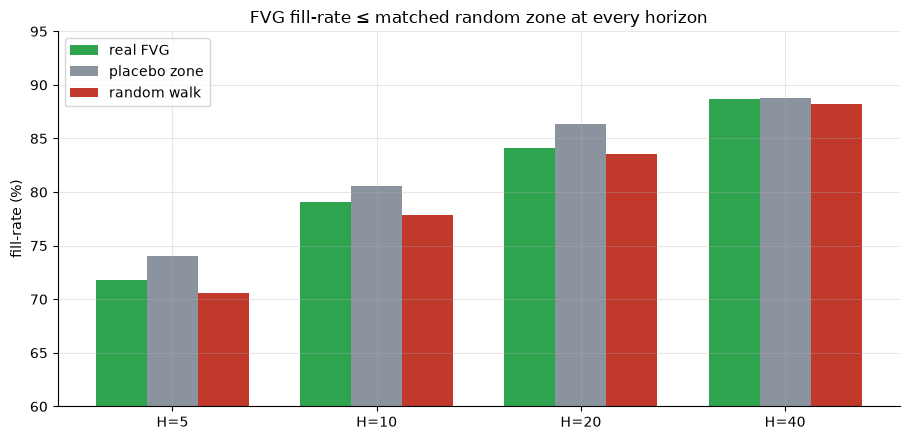

H= 5: real 71.8%  placebo 74.0%  z(real-plac)=-1.71
H=10: real 79.1%  placebo 80.5%  z(real-plac)=-1.20
H=20: real 84.2%  placebo 86.4%  z(real-plac)=-2.15
H=40: real 88.7%  placebo 88.8%  z(real-plac)=-0.05


In [2]:
if HAVE_REAL:
    g = st.find_fvgs(DF, min_rel=0.001)
    syn = data.synthetic_ohlc(n=len(DF), sigma=DF['close'].pct_change().std(), seed=353)
    sg = st.find_fvgs(syn, min_rel=0.001)
    Hs = [r[0] for r in R['fill']]; real=[]; plac=[]; synf=[]; zs=[]
    for H in Hs:
        r = st.fvg_fill_stats(DF, horizon=H, gaps=g)
        p = st.placebo_zone_fill(DF, g, horizon=H, seed=353)
        s = st.fvg_fill_stats(syn, horizon=H, gaps=sg)
        real.append(r['fill_rate']); plac.append(p['fill_rate']); synf.append(s['fill_rate'])
        zs.append(st.two_prop_z(round(r['fill_rate']*r['n']), r['n'], round(p['fill_rate']*p['n']), p['n']))
else:
    Hs=[r[0] for r in R['fill']]; real=[r[1] for r in R['fill']]
    plac=[r[2] for r in R['fill']]; synf=[r[3] for r in R['fill']]; zs=[r[4] for r in R['fill']]
x=np.arange(len(Hs)); fig,ax=plt.subplots(figsize=(9.2,4.5))
ax.bar(x-.25,[v*100 for v in real],.25,color=GREEN,label='real FVG')
ax.bar(x,    [v*100 for v in plac],.25,color=GREY, label='placebo zone')
ax.bar(x+.25,[v*100 for v in synf],.25,color=RED,  label='random walk')
ax.set_xticks(x); ax.set_xticklabels([f'H={h}' for h in Hs]); ax.set_ylim(60,95)
ax.set_ylabel('fill-rate (%)'); ax.set_title('FVG fill-rate ≤ matched random zone at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
for h,r,p,z in zip(Hs,real,plac,zs): print(f'H={h:2d}: real {r*100:.1f}%  placebo {p*100:.1f}%  z(real-plac)={z:+.2f}')

> 💡 In plain words: at H=20 real gaps fill **84.2%**, the placebo **86.4%** — the difference runs the **wrong way** (z = -2.15). H₁ rejected at every horizon. The fill-rate is a first-passage probability of a wandering price, identical for a random box.

### 4b · Order-block forward returns vs random entry — the Welch t

Signed forward 10-bar return entering on the first OB revisit (1-bar lag), against a random-entry control with the same horizon and a 50/50 long-short mix.

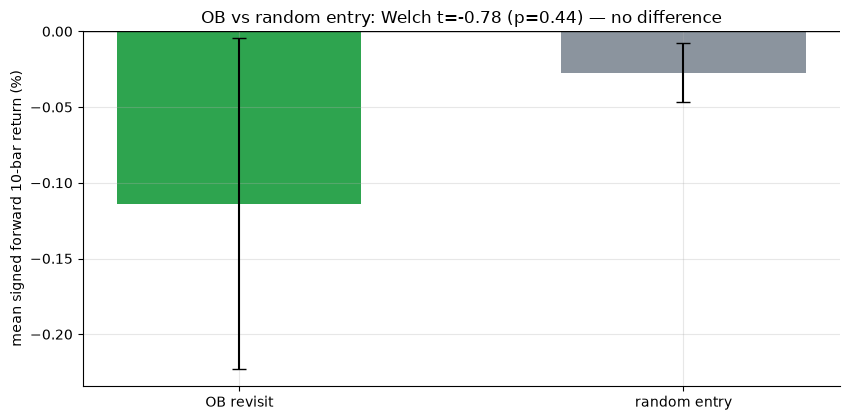

OB book : mean=-0.114%  t(vs0)=-1.04
random  : mean=-0.027%
Welch OB-random: t=-0.78  p=0.435


In [3]:
if HAVE_REAL:
    obs = st.find_order_blocks(DF, impulse=3, impulse_rel=0.015)
    ob  = st.ob_forward_returns(DF, obs, horizon=10, lag=1)
    rnd = st.random_entry_returns(DF, n_entries=ob['n']*20, horizon=10, lag=1, seed=353)
    w   = st.welch_t(ob['rets'], rnd['rets'])
    ob_m, ob_t, ob_se = ob['mean']*100, ob['t'], ob['std']/np.sqrt(ob['n'])*100
    rnd_m, rnd_se = rnd['mean']*100, rnd['std']/np.sqrt(rnd['n'])*100
    wt, wp = w['t'], w['p']
else:
    ob_m, ob_t, ob_se = R['ob_mean'], R['ob_t'], 0.11
    rnd_m, rnd_se = R['rnd_mean'], 0.02; wt, wp = R['welch_t'], R['welch_p']
fig, ax = plt.subplots(figsize=(8.6,4.3))
ax.bar(['OB revisit','random entry'], [ob_m, rnd_m], yerr=[ob_se, rnd_se],
       color=[GREEN, GREY], width=.55, capsize=5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean signed forward 10-bar return (%)')
ax.set_title(f'OB vs random entry: Welch t={wt:+.2f} (p={wp:.2f}) — no difference')
plt.tight_layout(); plt.show()
print(f'OB book : mean={ob_m:+.3f}%  t(vs0)={ob_t:+.2f}')
print(f'random  : mean={rnd_m:+.3f}%')
print(f'Welch OB-random: t={wt:+.2f}  p={wp:.3f}')

> 💡 In plain words: the OB book returns **-0.11%** (t=-1.04 vs 0 — a hair negative) and is statistically the same as random entry (Welch t=-0.78, p=0.43). H₂ rejected. The free parameters (impulse size, horizon) had every chance to find an edge **raw** and didn't — the cleanest possible negative.

### 4c · Costs only deepen a hole that's already there

Even granting a non-existent gross edge, charging the spread one-way on both legs of the round-trip makes the OB book strictly worse:

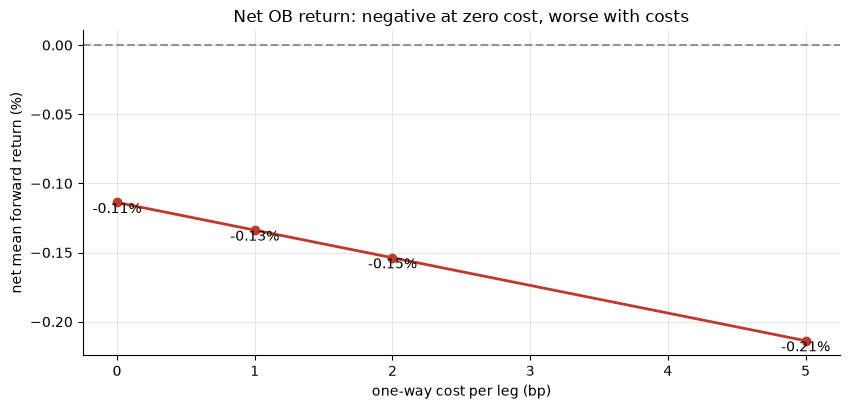

0bp/leg: net mean=-0.114%  t=-1.04
1bp/leg: net mean=-0.134%  t=-1.23
2bp/leg: net mean=-0.154%  t=-1.41
5bp/leg: net mean=-0.214%  t=-1.96


In [4]:
if HAVE_REAL:
    rets = ob['rets']
    bps = [0, 1, 2, 5]
    means = [st.net_of_costs(rets, b)['mean']*100 for b in bps]
    ts    = [st.net_of_costs(rets, b)['t'] for b in bps]
else:
    bps=[0,1,2,5]; means=[R['ob_mean'], R['ob_net1_mean'], -0.154, R['ob_net5_mean']]
    ts=[R['ob_t'], R['ob_net1_t'], -1.41, R['ob_net5_t']]
fig, ax = plt.subplots(figsize=(8.6,4.2))
ax.plot(bps, means, 'o-', c=RED, lw=2)
ax.axhline(0, ls='--', c=GREY); ax.set_xlabel('one-way cost per leg (bp)')
ax.set_ylabel('net mean forward return (%)')
ax.set_title('Net OB return: negative at zero cost, worse with costs')
for b,m in zip(bps,means): ax.annotate(f'{m:+.2f}%',(b,m),ha='center',va='top')
plt.tight_layout(); plt.show()
for b,m,t in zip(bps,means,ts): print(f'{b}bp/leg: net mean={m:+.3f}%  t={t:+.2f}')

> 💡 In plain words: the book is already **-0.11%** at zero cost; at 5 bp/leg it's **-0.21%** (t=-1.96). There is no cost level at which a negative gross edge becomes tradable. Tradability `MIRAGE` is over-determined.

### 4d · The positive control — the detector fires on pure noise

Run the identical detector on a driftless random walk (seed 353, σ matched to SPY). It **must** find gaps and order blocks — and it finds about as many as the real tape, filling and "bouncing" the same way. That's the proof the structures are geometry.

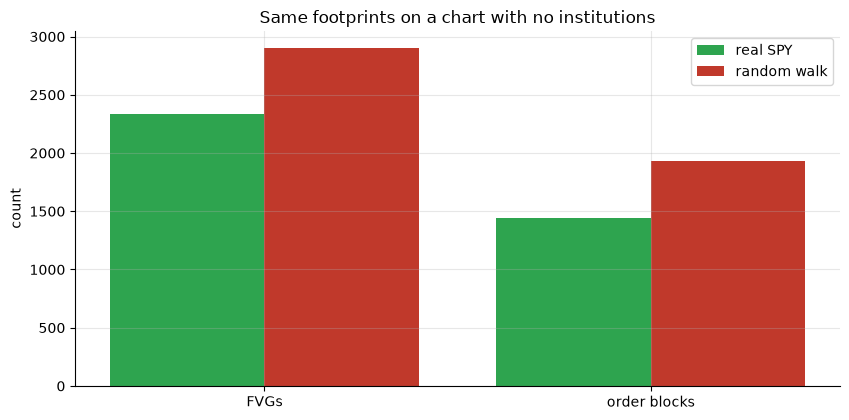

random walk: 2,900 FVGs (fill 83.6% @H20), 1,928 OBs (fwd t=-0.75)


In [5]:
syn = data.synthetic_ohlc(n=R['bars'], sigma=R['vol'], seed=353)
sg  = st.find_fvgs(syn, min_rel=0.001)
sob = st.find_order_blocks(syn, impulse=3, impulse_rel=0.015)
sfill = st.fvg_fill_stats(syn, horizon=20, gaps=sg)['fill_rate']
sret  = st.ob_forward_returns(syn, sob, horizon=10, lag=1)
labels = ['FVGs', 'order blocks']
real_counts = [R['n_fvg'], R['n_ob']]; syn_counts = [len(sg), len(sob)]
x=np.arange(2); fig,ax=plt.subplots(figsize=(8.6,4.3))
ax.bar(x-.2, real_counts, .4, color=GREEN, label='real SPY')
ax.bar(x+.2, syn_counts, .4, color=RED, label='random walk')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('count')
ax.set_title('Same footprints on a chart with no institutions'); ax.legend()
plt.tight_layout(); plt.show()
print(f'random walk: {len(sg):,} FVGs (fill {sfill*100:.1f}% @H20), {len(sob):,} OBs (fwd t={sret["t"]:+.2f})')

> 💡 In plain words: noise yields **2,900** FVGs filling **84%** and **1,933** OBs with a forward t of **-0.72** — indistinguishable from SPY. A footprint a memory-less process leaves in equal measure carries no information about who was trading.

## 5 · The verdict

- **Signal `NONE`** — FVG fill-rate ≤ placebo at every horizon (real−placebo z = -2.15 at H=20, wrong sign); OB forward return -0.11% (t=-1.04), Welch vs random entry t=-0.78 (p=0.43). No robust t ≥ 2 in the claim's direction anywhere.
- **Tradability `MIRAGE`** — gross signal absent; OB book -0.21% net of 5 bp/leg (t=-1.96). Nothing to scale.
- **Footprints? `NOT SUPPORTED`** — the synthetic control reproduces **2,900** FVGs (fill 84%) and **1,933** OBs (t=-0.72) on pure noise. The patterns are random-walk geometry, not institutional footprints.

## 6 · Could you trade it? — there is no edge to size

Beat 6 normally asks how much capital an edge holds. Here there is no edge: the FVG fill doesn't beat a random box, the OB return is statistically zero and indistinguishable from random entry, and both are reproduced by noise. The only honest sizing of a zero-edge, negative-after-costs rule is **zero**. The table below is the whole tradability case in one place.

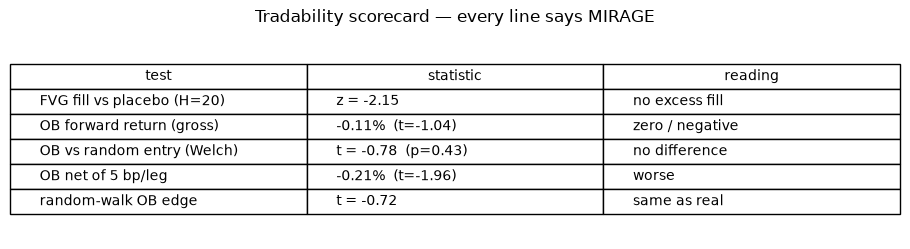

FVG fill vs placebo (H=20)     z = -2.15                -> no excess fill
OB forward return (gross)      -0.11%  (t=-1.04)        -> zero / negative
OB vs random entry (Welch)     t = -0.78  (p=0.43)      -> no difference
OB net of 5 bp/leg             -0.21%  (t=-1.96)        -> worse
random-walk OB edge            t = -0.72                -> same as real


In [6]:
rows = [
    ('FVG fill vs placebo (H=20)', f"z = {R['fill'][2][4]:+.2f}", 'no excess fill'),
    ('OB forward return (gross)',  f"{R['ob_mean']:+.2f}%  (t={R['ob_t']:+.2f})", 'zero / negative'),
    ('OB vs random entry (Welch)', f"t = {R['welch_t']:+.2f}  (p={R['welch_p']:.2f})", 'no difference'),
    ('OB net of 5 bp/leg',         f"{R['ob_net5_mean']:+.2f}%  (t={R['ob_net5_t']:+.2f})", 'worse'),
    ('random-walk OB edge',        f"t = {R['syn_ob_t']:+.2f}", 'same as real'),
]
fig, ax = plt.subplots(figsize=(9.2, 2.6)); ax.axis('off')
tbl = ax.table(cellText=[[a,b,c] for a,b,c in rows],
               colLabels=['test', 'statistic', 'reading'], loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
ax.set_title('Tradability scorecard — every line says MIRAGE', pad=12)
plt.tight_layout(); plt.show()
for a,b,c in rows: print(f'{a:30s} {b:24s} -> {c}')

> 💡 In plain words: there is no row that points to a harvestable edge. The signal is absent gross, negative net, and reproduced by a coin flip. Capacity is moot — you don't size a non-edge.

## 7 · Going further

- **Beat the null, not zero.** Any rescue of SMC — stricter FVG width, displacement+OB confluence, a specific session, multi-timeframe alignment — must be scored as **excess over the matched random walk / placebo zone**, with a t on the *difference*. A raw fill-rate or raw bounce is not admissible evidence.
- **First-passage framing.** The 84% fill-rate is a Brownian barrier-hitting probability for a fixed-width band near a diffusing price; model it in closed form and the "magnet" disappears analytically.
- **Multiple-testing honesty.** The OB rule already has free parameters (impulse δ, horizon) and fails *raw* — a White Reality Check over the parameter grid would only lower the bar further.

*The reproducible core is offline and deterministic (seed 353). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*